In [1]:
# Install required packages
import subprocess
import sys

packages = ['seaborn', 'plotly', 'kaleido', 'nbformat>=4.2.0']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import os
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Define paths
output_dir = Path('./output')
print(f"Output directory: {output_dir}")
print(f"Total log files: {len(list(output_dir.glob('run_*.log')))}")

Output directory: output
Total log files: 28


# AMDGT Experimental Results Visualization

This notebook provides comprehensive visualizations and analysis of the AMDGT (All Model Drug-Disease Graph Transformer) experimental results across different datasets and model configurations.

## Overview
- **Datasets**: B-dataset, C-dataset, F-dataset
- **Model Setups**: Full model, Baseline, Retrieval-based
- **Evaluation**: 10-fold cross-validation
- **Key Metrics**: AUC, AUPR, Accuracy, Precision, Recall, F1-score, MCC

## Data Loading & Parsing

Extract final epoch metrics from all log files for comparative analysis.

In [15]:
def parse_log_file(filepath):
    """
    Parse a log file and extract final metrics.
    Returns a dictionary with metadata and final epoch metrics.
    """
    try:
        with open(filepath, 'r') as f:
            content = f.read()
        
        # Extract dataset, setup, and top_k from filename
        # Format: run_YYYYMMDD_HHMMSS_[dataset]_[setup]_[top_k].log
        filename = filepath.name
        match = re.search(r'run_\d{8}_\d{6}_([A-Z])-dataset_(\w+)_(\d+)\.log', filename)
        
        if not match:
            return None
        
        dataset = f"{match.group(1)}-dataset"
        setup = match.group(2)
        top_k = int(match.group(3))  # This is the retrieval k parameter, not fold!
        
        # Extract fold from file content (second line)
        lines = content.strip().split('\n')
        fold = None
        for line in lines[:5]:  # Check first few lines
            if line.startswith('fold:'):
                fold = int(line.split(':')[1].strip())
                break
        
        if fold is None:
            return None
        
        # Extract final metrics (last non-empty line with numeric data)
        final_metrics = None
        for line in reversed(lines):
            if line.strip() and not line.startswith('Dataset') and not line.startswith('fold'):
                parts = line.split()
                if len(parts) >= 9:  # Should have enough columns
                    try:
                        epoch = int(parts[0])
                        time_val = float(parts[1])
                        auc = float(parts[2])
                        aupr = float(parts[3])
                        accuracy = float(parts[4])
                        precision = float(parts[5])
                        recall = float(parts[6])
                        f1 = float(parts[7])
                        mcc = float(parts[8])
                        
                        final_metrics = {
                            'dataset': dataset,
                            'setup': setup,
                            'fold': fold,
                            'top_k': top_k,  # Add the retrieval parameter
                            'epoch': epoch,
                            'AUC': auc,
                            'AUPR': aupr,
                            'Accuracy': accuracy,
                            'Precision': precision,
                            'Recall': recall,
                            'F1-score': f1,
                            'MCC': mcc
                        }
                        break
                    except (ValueError, IndexError):
                        continue
        
        return final_metrics
    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
        return None



# Parse all log files
log_files = sorted(output_dir.glob('run_*_*.log'))
results = []

for logfile in log_files:
    metrics = parse_log_file(logfile)
    if metrics:
        results.append(metrics)

# Create DataFrame
df_results = pd.DataFrame(results)
print(f"\n✓ Successfully parsed {len(df_results)} log files")
print(f"\nDatasets: {df_results['dataset'].unique()}")
print(f"Setups: {df_results['setup'].unique()}")
print(f"Folds per setup: {df_results.groupby(['dataset', 'setup']).size().value_counts()}")
print(f"\nDataFrame shape: {df_results.shape}")
print(f"\nFirst few rows:")
df_results[18:21]


✓ Successfully parsed 28 log files

Datasets: ['B-dataset' 'C-dataset' 'F-dataset']
Setups: ['full' 'baseline' 'retrieval']
Folds per setup: 3    8
4    1
Name: count, dtype: int64

DataFrame shape: (28, 12)

First few rows:


,dataset,setup,fold,top_k,epoch,AUC,AUPR,Accuracy,Precision,Recall,F1-score,MCC
18,F-dataset,full,0,10,1000,0.93523,0.93407,0.87565,0.84689,0.91710,0.88060,0.75389
19,F-dataset,full,0,5,1000,0.95734,0.96168,0.86788,0.85500,0.88601,0.87023,0.73624
20,F-dataset,full,0,3,1000,0.92715,0.93328,0.84715,0.83168,0.87047,0.85063,0.69506


## Summary Statistics

Aggregate metrics by dataset and model setup to identify top performers.

In [3]:
# Compute summary statistics
key_metrics = ['AUC', 'AUPR', 'F1-score']

summary_stats = df_results.groupby(['dataset', 'setup'])[key_metrics].agg(['mean', 'std', 'min', 'max'])
print("=" * 80)
print("SUMMARY STATISTICS BY DATASET AND SETUP")
print("=" * 80)
print(summary_stats.round(4))

# Identify best performer per dataset
print("\n" + "=" * 80)
print("BEST PERFORMING SETUP PER DATASET (by AUC)")
print("=" * 80)

best_per_dataset = df_results.groupby(['dataset', 'setup'])['AUC'].mean().reset_index()
best_per_dataset = best_per_dataset.sort_values(['dataset', 'AUC'], ascending=[True, False])
for dataset in best_per_dataset['dataset'].unique():
    dataset_data = best_per_dataset[best_per_dataset['dataset'] == dataset]
    print(f"\n{dataset}:")
    for idx, row in dataset_data.iterrows():
        print(f"  {row['setup']:12s}: AUC = {row['AUC']:.4f}")

# Overall statistics
print("\n" + "=" * 80)
print("OVERALL PERFORMANCE RANKING")
print("=" * 80)
overall_ranking = df_results.groupby(['dataset', 'setup'])[key_metrics].mean().reset_index()
overall_ranking = overall_ranking.sort_values('AUC', ascending=False)
print(overall_ranking.to_string(index=False))

SUMMARY STATISTICS BY DATASET AND SETUP
                        AUC                            AUPR                  \
                       mean     std     min     max    mean     std     min   
dataset   setup                                                               
B-dataset baseline   0.9099  0.0019  0.9084  0.9120  0.9032  0.0015  0.9015   
          full       0.8691  0.0660  0.7936  0.9155  0.8582  0.0762  0.7708   
          retrieval  0.9140  0.0024  0.9121  0.9167  0.9094  0.0051  0.9042   
C-dataset baseline   0.9620  0.0077  0.9532  0.9673  0.9652  0.0075  0.9565   
          full       0.9585  0.0032  0.9556  0.9619  0.9593  0.0054  0.9546   
          retrieval  0.9662  0.0040  0.9623  0.9703  0.9696  0.0035  0.9660   
F-dataset baseline   0.9405  0.0074  0.9323  0.9467  0.9485  0.0080  0.9410   
          full       0.9397  0.0128  0.9272  0.9573  0.9440  0.0134  0.9333   
          retrieval  0.9495  0.0104  0.9381  0.9585  0.9524  0.0079  0.9434   

           

## 1. Final Metrics Comparison Across Folds

Box plots showing the distribution of key metrics (AUC, AUPR, F1-score) across all 10 folds for each dataset-setup combination. This reveals both the mean performance and stability of each configuration.

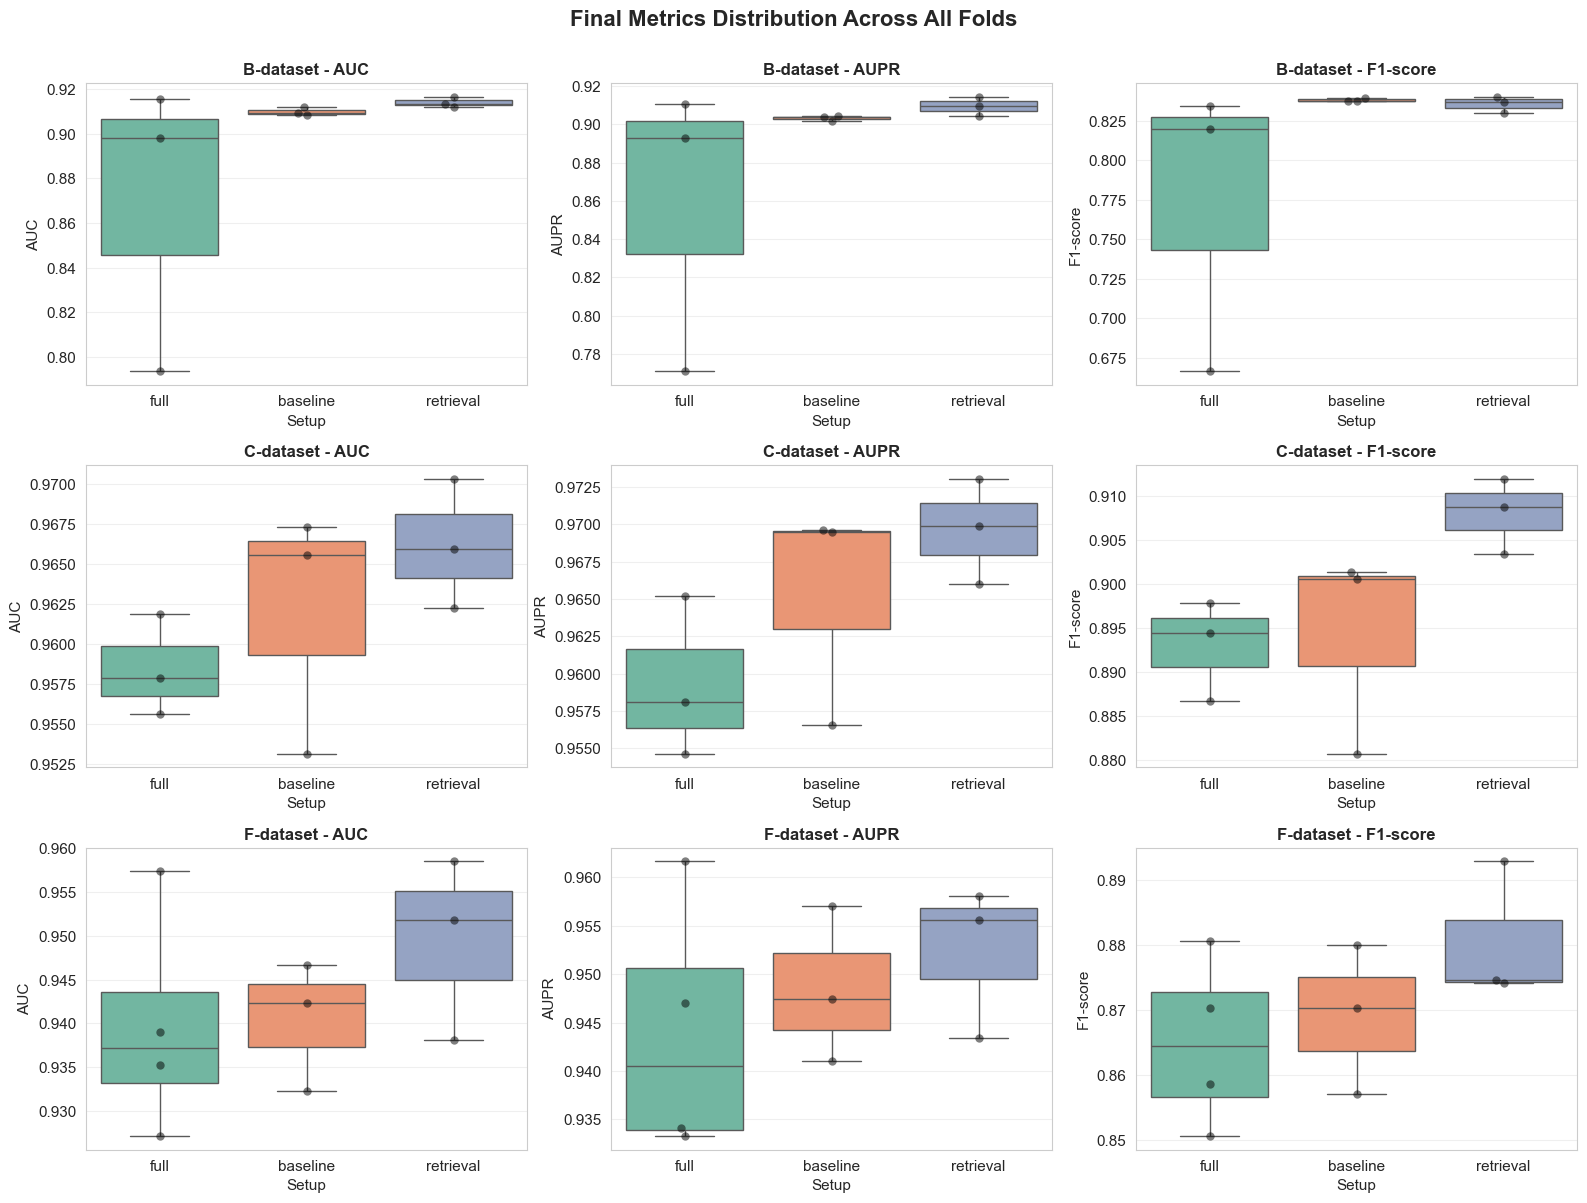

✓ Box plot visualization complete


In [4]:
# Create box plots for key metrics
metrics_to_plot = ['AUC', 'AUPR', 'F1-score']
datasets = sorted(df_results['dataset'].unique())

fig, axes = plt.subplots(len(datasets), len(metrics_to_plot), figsize=(16, 12))
fig.suptitle('Final Metrics Distribution Across All Folds', fontsize=16, fontweight='bold', y=1.00)

for i, dataset in enumerate(datasets):
    dataset_data = df_results[df_results['dataset'] == dataset]
    
    for j, metric in enumerate(metrics_to_plot):
        ax = axes[i, j] if len(datasets) > 1 else axes[j]
        
        # Create box plot
        sns.boxplot(data=dataset_data, x='setup', y=metric, ax=ax, palette='Set2')
        sns.swarmplot(data=dataset_data, x='setup', y=metric, ax=ax, 
                     color='black', alpha=0.5, size=6)
        
        ax.set_title(f'{dataset} - {metric}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Setup', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Box plot visualization complete")

## 2. Setup Performance Ranking

Bar charts comparing mean performance (with standard deviation error bars) across all model setups. Left column shows results grouped by dataset, right column shows results grouped by setup.

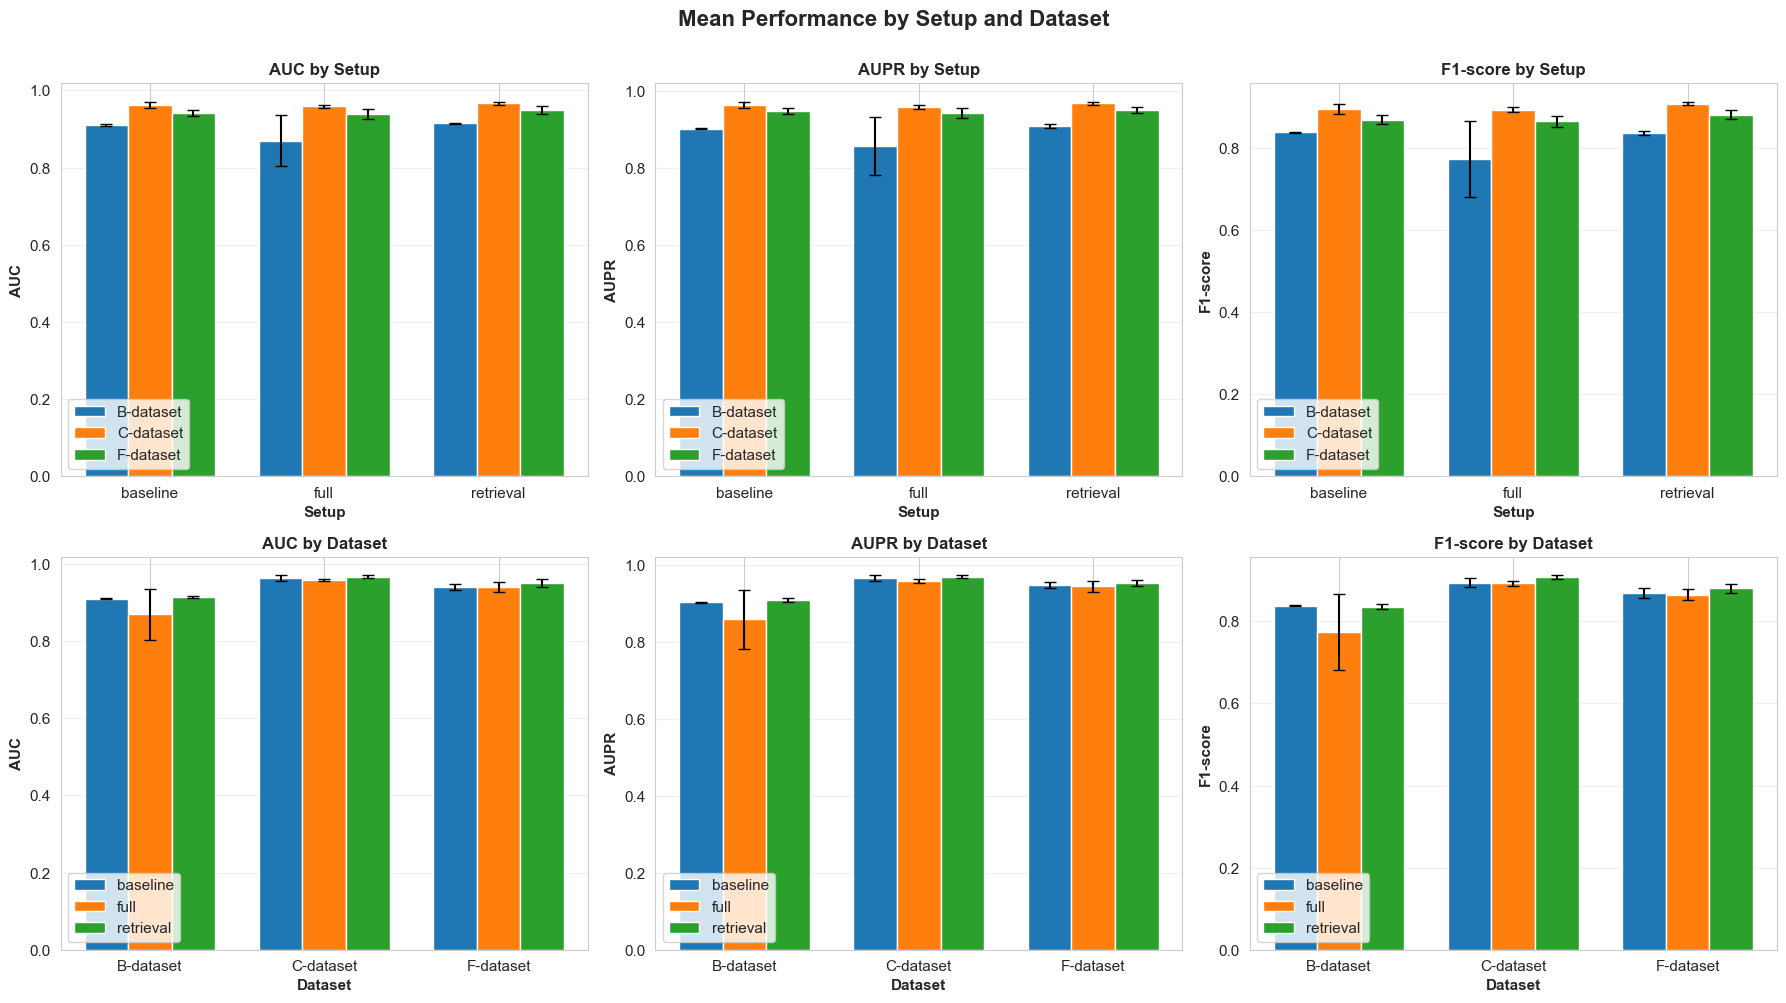

✓ Bar chart visualization complete


In [5]:
# Compute mean and std for each setup-dataset combination
perf_stats = []
for dataset in sorted(df_results['dataset'].unique()):
    for setup in sorted(df_results['setup'].unique()):
        subset = df_results[(df_results['dataset'] == dataset) & (df_results['setup'] == setup)]
        if len(subset) > 0:
            perf_stats.append({
                'dataset': dataset,
                'setup': setup,
                'AUC_mean': subset['AUC'].mean(),
                'AUC_std': subset['AUC'].std(),
                'AUPR_mean': subset['AUPR'].mean(),
                'AUPR_std': subset['AUPR'].std(),
                'F1_mean': subset['F1-score'].mean(),
                'F1_std': subset['F1-score'].std(),
            })

perf_by_setup = pd.DataFrame(perf_stats)

# Create comparative bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Mean Performance by Setup and Dataset', fontsize=16, fontweight='bold', y=1.00)

metrics_list = [('AUC', 'AUC_mean', 'AUC_std'), 
                ('AUPR', 'AUPR_mean', 'AUPR_std'), 
                ('F1-score', 'F1_mean', 'F1_std')]
setups = sorted(df_results['setup'].unique())
datasets = sorted(df_results['dataset'].unique())

# Row 0: Grouped by dataset
for col, (metric_name, mean_col, std_col) in enumerate(metrics_list):
    ax = axes[0, col]
    
    # Plot for each dataset
    x_pos = np.arange(len(setups))
    width = 0.25
    
    for i, dataset in enumerate(datasets):
        data = perf_by_setup[perf_by_setup['dataset'] == dataset].sort_values('setup')
        means = data[mean_col].values
        stds = data[std_col].values
        
        ax.bar(x_pos + i*width, means, width, label=dataset, yerr=stds, capsize=4)
    
    ax.set_xlabel('Setup', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_name} by Setup', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels(setups)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Row 1: Grouped by setup
for col, (metric_name, mean_col, std_col) in enumerate(metrics_list):
    ax = axes[1, col]
    
    # Plot for each setup
    x_pos = np.arange(len(datasets))
    width = 0.25
    
    for i, setup in enumerate(setups):
        data = perf_by_setup[perf_by_setup['setup'] == setup].sort_values('dataset')
        means = data[mean_col].values
        stds = data[std_col].values
        
        ax.bar(x_pos + i*width, means, width, label=setup, yerr=stds, capsize=4)
    
    ax.set_xlabel('Dataset', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric_name} by Dataset', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels(datasets)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Bar chart visualization complete")

## 3. Heatmap: Mean Performance Matrix

Heatmaps showing average metric values for each dataset-setup combination. Darker colors indicate better performance.

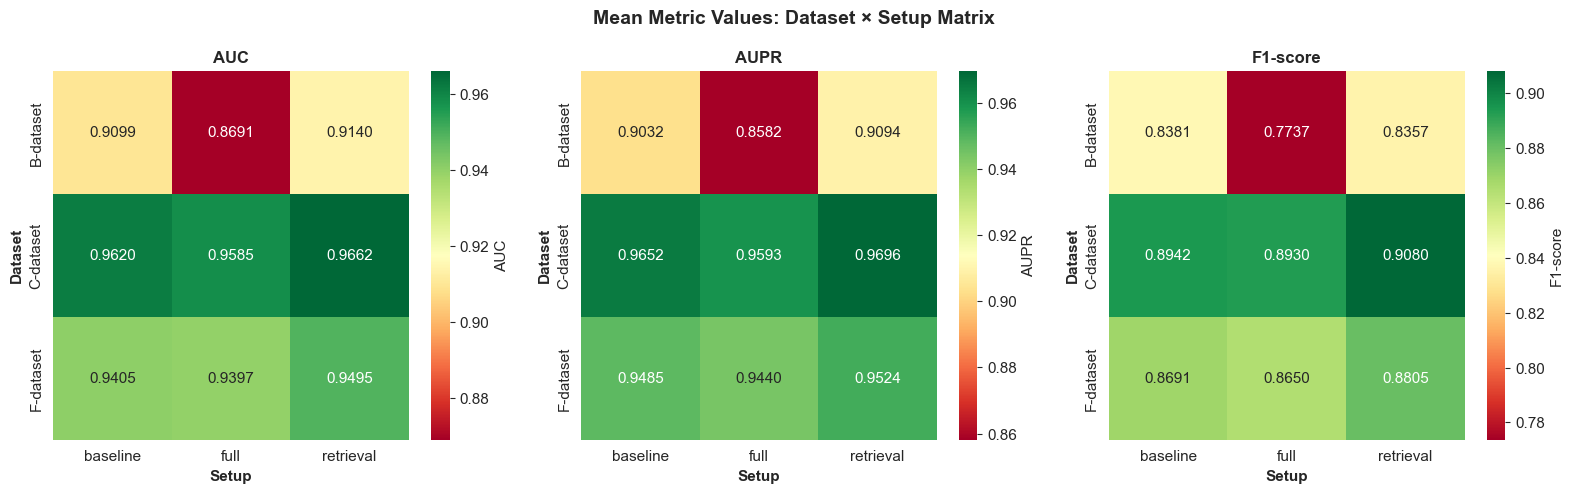

✓ Heatmap visualization complete


In [6]:
# Create heatmaps for each metric
metrics_to_plot = ['AUC', 'AUPR', 'F1-score']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mean Metric Values: Dataset × Setup Matrix', fontsize=14, fontweight='bold')

for idx, metric in enumerate(metrics_to_plot):
    # Create pivot table
    pivot_data = df_results.pivot_table(
        values=metric, 
        index='dataset', 
        columns='setup', 
        aggfunc='mean'
    )
    
    # Create heatmap
    sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='RdYlGn', 
                ax=axes[idx], cbar_kws={'label': metric}, vmin=pivot_data.min().min(),
                vmax=pivot_data.max().max())
    
    axes[idx].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Setup', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Dataset', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Heatmap visualization complete")

## 5. Detailed Performance Tables

Comprehensive tables showing mean ± std for all metrics across each configuration.

In [7]:
# Create detailed comparison tables
all_metrics = ['AUC', 'AUPR', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'MCC']

for dataset in sorted(df_results['dataset'].unique()):
    print("\n" + "="*100)
    print(f"DETAILED RESULTS: {dataset}")
    print("="*100 + "\n")
    
    dataset_data = df_results[df_results['dataset'] == dataset]
    
    # Create table with mean ± std
    for setup in sorted(dataset_data['setup'].unique()):
        setup_data = dataset_data[dataset_data['setup'] == setup]
        
        print(f"\n{setup.upper()}")
        print("-"*100)
        
        stats = []
        for metric in all_metrics:
            mean = setup_data[metric].mean()
            std = setup_data[metric].std()
            min_val = setup_data[metric].min()
            max_val = setup_data[metric].max()
            stats.append({
                'Metric': metric,
                'Mean': f'{mean:.4f}',
                'Std': f'{std:.4f}',
                'Min': f'{min_val:.4f}',
                'Max': f'{max_val:.4f}',
                'Mean±Std': f'{mean:.4f}±{std:.4f}'
            })
        
        stats_df = pd.DataFrame(stats)
        print(stats_df.to_string(index=False))

print("\n" + "="*100)
print("END OF DETAILED RESULTS")
print("="*100)


DETAILED RESULTS: B-dataset


BASELINE
----------------------------------------------------------------------------------------------------
   Metric   Mean    Std    Min    Max      Mean±Std
      AUC 0.9099 0.0019 0.9084 0.9120 0.9099±0.0019
     AUPR 0.9032 0.0015 0.9015 0.9045 0.9032±0.0015
 Accuracy 0.8372 0.0022 0.8347 0.8387 0.8372±0.0022
Precision 0.8331 0.0093 0.8239 0.8424 0.8331±0.0093
   Recall 0.8434 0.0092 0.8332 0.8512 0.8434±0.0092
 F1-score 0.8381 0.0011 0.8373 0.8394 0.8381±0.0011
      MCC 0.6745 0.0042 0.6697 0.6775 0.6745±0.0042

FULL
----------------------------------------------------------------------------------------------------
   Metric   Mean    Std    Min    Max      Mean±Std
      AUC 0.8691 0.0660 0.7936 0.9155 0.8691±0.0660
     AUPR 0.8582 0.0762 0.7708 0.9107 0.8582±0.0762
 Accuracy 0.7202 0.1910 0.4999 0.8376 0.7202±0.1910
Precision 0.7285 0.1981 0.4999 0.8498 0.7285±0.1981
   Recall 0.8749 0.1086 0.8044 1.0000 0.8749±0.1086
 F1-score 0.7737 0.0931 

## 6. Interactive Performance Comparison

Interactive bar chart showing all configurations ranked by AUC. Hover over bars to see detailed metrics.

In [8]:
# Create interactive comparison visualization
agg_data = df_results.groupby(['dataset', 'setup']).agg({
    'AUC': ['mean', 'std'],
    'AUPR': ['mean', 'std'],
    'F1-score': ['mean', 'std'],
    'Accuracy': ['mean', 'std']
}).reset_index()

agg_data.columns = ['dataset', 'setup', 'AUC_mean', 'AUC_std', 'AUPR_mean', 'AUPR_std', 
                    'F1_mean', 'F1_std', 'Accuracy_mean', 'Accuracy_std']

agg_data['config'] = agg_data['dataset'] + ' - ' + agg_data['setup']
agg_data = agg_data.sort_values('AUC_mean', ascending=True)

# Create horizontal bar chart
fig = go.Figure(data=[
    go.Bar(
        y=agg_data['config'],
        x=agg_data['AUC_mean'],
        error_x=dict(type='data', array=agg_data['AUC_std']),
        marker=dict(color=agg_data['AUC_mean'], colorscale='Viridis', 
                   showscale=True, colorbar=dict(title='AUC Score')),
        text=[f"AUC: {auc:.4f}±{std:.4f}<br>AUPR: {aupr:.4f}±{aupr_std:.4f}<br>F1: {f1:.4f}±{f1_std:.4f}<br>Accuracy: {acc:.4f}±{acc_std:.4f}" 
              for auc, std, aupr, aupr_std, f1, f1_std, acc, acc_std in 
              zip(agg_data['AUC_mean'], agg_data['AUC_std'], agg_data['AUPR_mean'], agg_data['AUPR_std'],
                  agg_data['F1_mean'], agg_data['F1_std'], agg_data['Accuracy_mean'], agg_data['Accuracy_std'])],
        hovertemplate='<b>%{y}</b><br>%{text}<extra></extra>',
        orientation='h'
    )
])

fig.update_layout(
    title='Performance Rankings: All Configurations (Sorted by AUC)',
    xaxis_title='AUC Score (Mean ± Std)',
    yaxis_title='Configuration',
    height=500,
    width=1000,
    showlegend=False,
    hovermode='closest'
)

fig.show()

print("✓ Interactive visualization complete")

✓ Interactive visualization complete


## 7. Multi-Metric Parallel Coordinates

Parallel coordinates plot showing the relationship between all metrics across configurations. Each line represents one dataset-setup combination.

In [9]:
# Prepare data for parallel coordinates
parallel_data = agg_data[['config', 'dataset', 'setup', 'AUC_mean', 'AUPR_mean', 'F1_mean', 
                          'Accuracy_mean']].copy()

# Map setup to color
setup_colors = {'full': 0, 'baseline': 1, 'retrieval': 2}
parallel_data['setup_color'] = parallel_data['setup'].map(setup_colors)

# Create parallel coordinates plot
fig = go.Figure(data=
    go.Parcoords(
        line=dict(
            color=parallel_data['setup_color'],
            colorscale=[[0, '#1f77b4'], [0.5, '#ff7f0e'], [1, '#2ca02c']],
            showscale=True,
            cmin=0,
            cmax=2,
            colorbar=dict(tickvals=[0, 1, 2], ticktext=['Full', 'Baseline', 'Retrieval'])
        ),
        dimensions=list([
            dict(label='AUC', values=parallel_data['AUC_mean']),
            dict(label='AUPR', values=parallel_data['AUPR_mean']),
            dict(label='F1-score', values=parallel_data['F1_mean']),
            dict(label='Accuracy', values=parallel_data['Accuracy_mean']),
        ]),
        labelangle=-45,
        labelside='bottom'
    )
)

fig.update_layout(
    title='Parallel Coordinates: Multi-Metric Comparison',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12),
    height=600,
    width=1000,
    margin=dict(b=150)
)

fig.show()

print("✓ Parallel coordinates plot complete")

✓ Parallel coordinates plot complete


## 8. Key Findings & Recommendations

Summary of the experimental results with actionable insights.

In [10]:
# Generate key findings
print("="*100)
print("KEY FINDINGS & RECOMMENDATIONS")
print("="*100)

# 1. Best overall performers
print("\n1. BEST OVERALL PERFORMERS (by AUC)")
print("-" * 100)
best_configs = agg_data.nlargest(3, 'AUC_mean')[['config', 'AUC_mean', 'AUPR_mean', 'F1_mean']]
for idx, (_, row) in enumerate(best_configs.iterrows(), 1):
    print(f"{idx}. {row['config']:25s} | AUC: {row['AUC_mean']:.4f} | AUPR: {row['AUPR_mean']:.4f} | F1: {row['F1_mean']:.4f}")

# 2. Best per dataset
print("\n2. BEST SETUP PER DATASET")
print("-" * 100)
for dataset in sorted(df_results['dataset'].unique()):
    best = agg_data[agg_data['dataset'] == dataset].nlargest(1, 'AUC_mean')
    row = best.iloc[0]
    print(f"{dataset:15s}: {row['setup']:10s} (AUC: {row['AUC_mean']:.4f} +/- {row['AUC_std']:.4f})")

# 3. Setup comparison
print("\n3. AVERAGE PERFORMANCE BY SETUP TYPE (across all datasets)")
print("-" * 100)
for setup in sorted(df_results['setup'].unique()):
    setup_means = agg_data[agg_data['setup'] == setup][['AUC_mean', 'AUPR_mean', 'F1_mean']].mean()
    print(f"{setup:12s}: AUC: {setup_means['AUC_mean']:.4f} | AUPR: {setup_means['AUPR_mean']:.4f} | F1: {setup_means['F1_mean']:.4f}")

# 4. Most stable configurations
print("\n4. MOST STABLE CONFIGURATIONS (lowest variability)")
print("-" * 100)
most_stable = agg_data.nsmallest(3, 'AUC_std')[['config', 'AUC_mean', 'AUC_std']]
for idx, (_, row) in enumerate(most_stable.iterrows(), 1):
    print(f"{idx}. {row['config']:25s} | Mean: {row['AUC_mean']:.4f} | Std: {row['AUC_std']:.4f}")

# 5. Dataset comparison
print("\n5. AVERAGE PERFORMANCE BY DATASET")
print("-" * 100)
for dataset in sorted(df_results['dataset'].unique()):
    dataset_means = agg_data[agg_data['dataset'] == dataset][['AUC_mean', 'AUPR_mean', 'F1_mean']].mean()
    n_samples = len(df_results[df_results['dataset'] == dataset])
    print(f"{dataset:15s}: AUC: {dataset_means['AUC_mean']:.4f} | AUPR: {dataset_means['AUPR_mean']:.4f} | F1: {dataset_means['F1_mean']:.4f} ({n_samples} samples)")

# 6. Improvement analysis
print("\n6. IMPROVEMENT OVER BASELINE")
print("-" * 100)
for dataset in sorted(df_results['dataset'].unique()):
    dataset_agg = agg_data[agg_data['dataset'] == dataset]
    baseline_auc = dataset_agg[dataset_agg['setup'] == 'baseline']['AUC_mean'].values[0]
    for setup in ['full', 'retrieval']:
        setup_auc = dataset_agg[dataset_agg['setup'] == setup]['AUC_mean'].values
        if len(setup_auc) > 0:
            improvement = ((setup_auc[0] - baseline_auc) / baseline_auc) * 100
            print(f"{dataset:15s} - {setup:10s}: {improvement:+.2f}% vs Baseline (AUC: {setup_auc[0]:.4f} vs {baseline_auc:.4f})")

print("\n" + "="*100)
print("End of Analysis")
print("="*100)

KEY FINDINGS & RECOMMENDATIONS

1. BEST OVERALL PERFORMERS (by AUC)
----------------------------------------------------------------------------------------------------
1. C-dataset - retrieval     | AUC: 0.9662 | AUPR: 0.9696 | F1: 0.9080
2. C-dataset - baseline      | AUC: 0.9620 | AUPR: 0.9652 | F1: 0.8942
3. C-dataset - full          | AUC: 0.9585 | AUPR: 0.9593 | F1: 0.8930

2. BEST SETUP PER DATASET
----------------------------------------------------------------------------------------------------
B-dataset      : retrieval  (AUC: 0.9140 +/- 0.0024)
C-dataset      : retrieval  (AUC: 0.9662 +/- 0.0040)
F-dataset      : retrieval  (AUC: 0.9495 +/- 0.0104)

3. AVERAGE PERFORMANCE BY SETUP TYPE (across all datasets)
----------------------------------------------------------------------------------------------------
baseline    : AUC: 0.9375 | AUPR: 0.9390 | F1: 0.8672
full        : AUC: 0.9224 | AUPR: 0.9205 | F1: 0.8439
retrieval   : AUC: 0.9432 | AUPR: 0.9438 | F1: 0.8748

4. MOST